In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
from pydantic import BaseModel,Field
import  operator
load_dotenv()

True

In [11]:
# LLM Configuration - DeepSeek R1 Distill Qwen 7B
LLAMA_STUDIO_API_BASE = os.getenv("LLAMA_STUDIO_API_BASE", "http://localhost:1234/v1")
LLAMA_STUDIO_API_KEY = os.getenv("LLAMA_STUDIO_API_KEY", "lm-studio")
LLM_MODEL_NAME = os.getenv("LLM_MODEL_NAME", "deepseek-r1-distill-qwen-7b")
LLM_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0.7"))
LLM_MAX_TOKENS = int(os.getenv("LLM_MAX_TOKENS", "2048"))
LLM_TIMEOUT = int(os.getenv("LLM_TIMEOUT", "60"))  # Timeout in seconds
LLM_MAX_RETRIES = int(os.getenv("LLM_MAX_RETRIES", "2"))  # Number of retries

In [12]:
model = ChatOpenAI(
        base_url=LLAMA_STUDIO_API_BASE,
        api_key=LLAMA_STUDIO_API_KEY,
        model=LLM_MODEL_NAME,
        temperature=LLM_TEMPERATURE,
        max_tokens=LLM_MAX_TOKENS,
        timeout=LLM_TIMEOUT,
        max_retries=LLM_MAX_RETRIES,
      
    )

In [13]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

str_model_2 = model.with_structured_output(DiagnosisSchema)

In [14]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description='Sentiment of the review')
str_model = model.with_structured_output(SentimentSchema)

In [15]:
prompt = f'What is the sentiment of the following review -  the software is too bad'
str_model.invoke(prompt).sentiment

'negative'

In [16]:
#define state   
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['positive','negative']
    diagnosis:dict
    response:str
    


In [33]:
def find_sentiment(state:ReviewState) -> ReviewState:

    prompt = f'What is the sentiment of the following review - {state["review"]}'
    # call lllm for outline 
    output = str_model.invoke(prompt)

    return {'sentiment':output.sentiment}

def check_sentiment(state:ReviewState) -> Literal['positive_response','run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state:ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content
    return {'response':response}
def run_diagnosis(state:ReviewState):
    
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = str_model_2.invoke(prompt)

    return {'diagnosis': response.model_dump()}
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [34]:
# define graph 
graph = StateGraph(ReviewState)

# add nodes
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)
graph.add_node('run_diagnosis',run_diagnosis)




# add edges to graph 
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

#compile the graph 
workflow = graph.compile()

# execute the graph

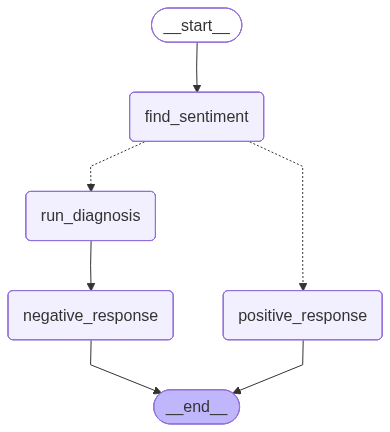

In [35]:
workflow

In [36]:
review ="""I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."""

In [37]:
intital_state = {'review':review}
workflow.invoke(intital_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Okay, I understand you've encountered a bug that's causing frustration – and I really appreciate you flagging it as urgent! I want to assure you that I'm here to help get this resolved for you as quickly as possible. \n\nI can definitely see how frustrating it can be when things don't work as expected, especially when it impacts your workflow. \n\nTo help me assist you effectively, could you please tell me a little more about the bug?  The more details you can provide (steps to reproduce, expected vs. actual behavior, any error messages), the better I can understand the issue and find a solution. \n\nI'll do my best to guide you 

## The Rise of AI in Pakistan: Opportunities, Challenges, and Future Potential

**(Image: A modern image depicting technology merging with Pakistani culture – e.g., a digital representation of a farmer using an AI-powered tool in a field.)**

Artificial intelligence is rapidly transforming industries worldwide, and Pakistan is poised to be a key player in this revolution. From self-driving cars to personalized medicine, AI’s influence is undeniable. But what does the future hold for artificial intelligence within Pakistan? This blog post dives deep into the current landscape of AI adoption, explores its immense opportunities, tackles the challenges hindering progress, and envisions the potential for AI to shape Pakistan's future.  We'll cover everything from healthcare advancements to economic growth drivers – painting a comprehensive picture of where Pakistan stands and where it’s headed in this exciting field.



**II. The Current Landscape of AI in Pakistan (Approx. 350 words)**

AI

In [9]:
print(final_state['evalaute'])

## Blog Post Rating: 9.5/10

**Here's a breakdown of why it's so good and areas where it excels:**

**Strengths:**

*   **Comprehensive & Detailed:** The outline is extremely thorough, covering all the necessary aspects of AI in Pakistan – from opportunities to challenges and future potential.  The detail provided throughout the draft makes it highly credible and well-researched.
*   **Well-Structured & Organized:** The logical flow of information is excellent. Each section builds upon the previous one, providing a cohesive narrative. 
*   **Clear & Accessible Language:**  The language used is easy to understand for a general audience, avoiding technical jargon where possible.  It balances accessibility with depth.
*   **Actionable Insights:** The "Call to Action" adds a nice touch and encourages reader engagement.
*   **Addresses Key Considerations:** Includes the crucial reminder about data availability, talent gaps, ethical concerns, and regulatory frameworks – all critical areas fo

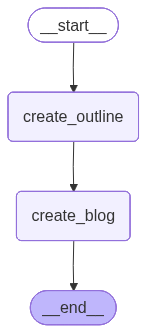

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())